## Housing Price Prediction

- Download housing dataset in the tarball format
- Extract dataset file into dataset folder which is created or pre-existed
- Load extracted csv dataset file using pandas read_csv method

In [124]:
from pathlib import Path
import pandas as pd
import tarfile
import urllib.request

def load_housing_data():
    tarball_path = Path("datasets/housing.tgz")
    if not tarball_path.is_file():
        Path("datasets").mkdir(parents=True, exist_ok=True)
    url = "https://github.com/ageron/data/raw/main/housing.tgz"
    urllib.request.urlretrieve(url, tarball_path)
    with tarfile.open(tarball_path) as housing_tarball:
        housing_tarball.extractall(path="datasets")
    return pd.read_csv(Path("datasets/housing/housing.csv"))

housing = load_housing_data()
housing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [ ]:
housing.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


- Above shown list of features of housing dataset 
- Only ocean proximity is the type of string, all other features are floating 64 bit numbers

In [126]:
val_counts = housing['ocean_proximity'].value_counts()
val_counts

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

- Looking at the bar chart, we can see majority of houses are located inland or one-hour distance from the ocean

<BarContainer object of 5 artists>

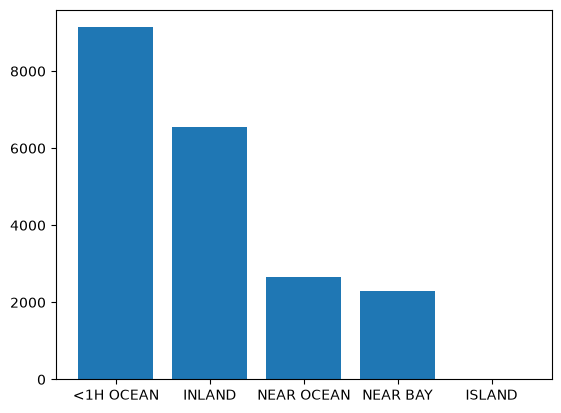

In [127]:
import matplotlib.pyplot as plt
plt.bar(val_counts.index, val_counts)

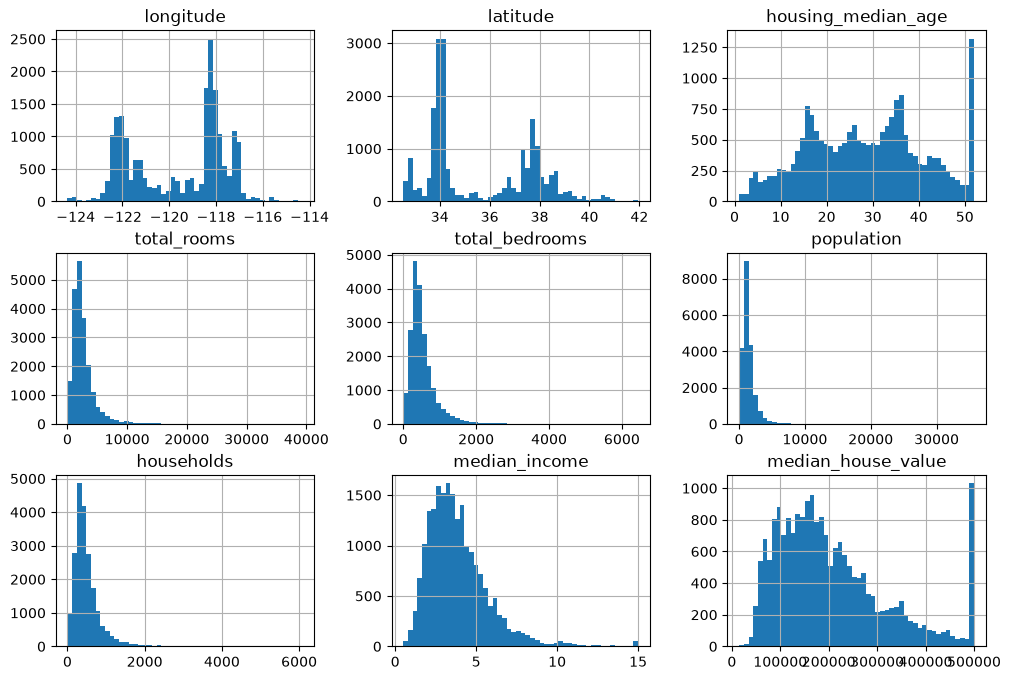

In [128]:
housing.hist(bins=50, figsize=(12, 8))
plt.show()

- `median_income` feature does not look like it is US dollars because house prices is max is 15. So we can assume these numbers represents x $10.000
- these does not mean the data is wrong but we should notice these transformation/patterns/caps
- Not only median income, but also median age and median value features also look like capped to 50 and $500K respectively
- All attributes has very different scales for example, age is 0-50, while house value is in the range of 0-500K
- When it comes to skeewness of histograms, we can see most of them are skewed right (right side of graph shape is signiifcantly bigger than rest of it, that is, many ML models struggle to learn patterns)  


##### So we explored some patterns about housing dataset which gives important information to use later in preprocessing stage to prepare our dataset for training models to predict most precice predictions  

- One job should be done right before data preprocessing is to split data into train and test subsets (optionally validation set too). 
- We will do some preprocess training set by applying cleaning and transformations before choosing the right model to train on. 

In [129]:
import numpy as np
def shuffle_split_data(data, test_ratio):
    shuffled_indices = np.random.permutation(len(data))
    test_set_size = int(len(data) * test_ratio)
    test_indices = shuffled_indices[:test_set_size]
    train_indices = shuffled_indices[test_set_size:]
    return data.iloc[train_indices], data.iloc[test_indices]

- Here we made our basic shuflled data splitter function
- However, we can use built-in `train_test_split` function provided in `sklearn.model_selection`

16512 by 4128


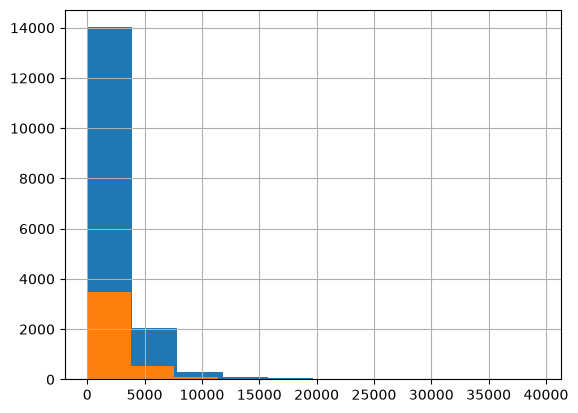

In [130]:
train_set, test_set = shuffle_split_data(housing, 0.2)
print(len(train_set), "by", len(test_set))


train_set["total_rooms"].hist()
test_set["total_rooms"].hist()
plt.show()

- As we can see from the out puts we splitted our data exactly 8 by 2 ratio and 
- shuffling resulted in the bar graph above which has two charts sharing similar right-skewed shape

- Since we are shuffling our data randomly and split every time, after several tries the instances in train set in previous splits may appear in test sets
- Solution is to use unique ID for each instance when splitting
- But our dataset has no unique id for each record 
- We can either combine `longitude`+`lattitude` features to make unique ID for each instance because they are unique together or can use `reset_index` method to add incremental integer column as an index

In [131]:
from zlib import crc32

def is_id_in_test_set(identifier, test_ratio):
    return crc32(np.int64(identifier)) < test_ratio * 2**32

def split_data_by_id_hash(data, test_ratio, id_column):
    ids = data[id_column]
    in_test_set = ids.apply(lambda id_: is_id_in_test_set(id_, test_ratio))
    return data.loc[~in_test_set], data.loc[in_test_set]

#### Using index column

In [132]:
housing_with_id = housing.reset_index()
train_set, test_set = split_data_by_id_hash(housing_with_id, 0.2, "index")

#### Using uique ID column

In [133]:
housing_with_id["id"] = housing["longitude"] * 1000 + housing["latitude"]
train_set, test_set = split_data_by_id_hash(housing_with_id, 0.2, "id")

print(train_set.shape, test_set.shape)

housing_with_id[["id"]].head()

(16322, 12) (4318, 12)


,id
0,-122192.12
1,-122182.14
2,-122202.15
3,-122212.15
4,-122212.15


#### Using `train_test_split` method

(16512, 10) (4128, 10)


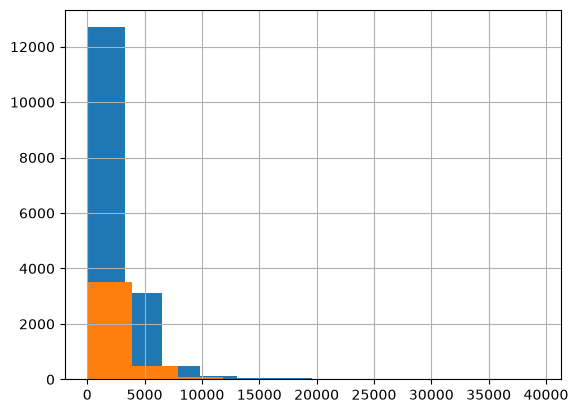

In [134]:
from sklearn.model_selection import train_test_split
train_set, test_set = train_test_split(housing, test_size=0.2, random_state=42)

print(train_set.shape, test_set.shape)

train_set["total_rooms"].hist()
test_set["total_rooms"].hist()
plt.show()

- To ensure the test set is to be representative of various categories of incomes of the whole dataset, we first should create income category attribure
- `pd.cut()` method can make different income categories (startums) ranging from every 1.5 (15K)
- we should also ensure that each cateogory/startum is large enough, then we split based on this attribute, this process is called as `startified-sampling`

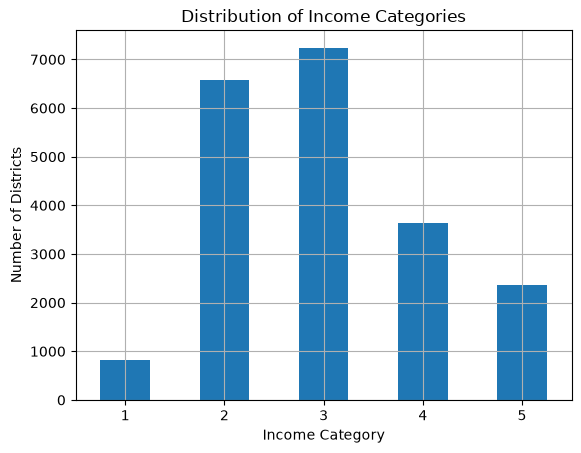

In [135]:
housing['income_cat'] = pd.cut(housing['median_income'],
                               bins=[0., 1.5, 3.0, 4.5, 6., np.inf],
                               labels=[1, 2, 3, 4, 5])
housing['income_cat'].value_counts().sort_index().plot.bar(rot=0, grid=True)
plt.xlabel('Income Category')
plt.ylabel('Number of Districts')
plt.title('Distribution of Income Categories')
plt.show()


- Having multiple splits might be useful if we want to better estimate the performance of our model, using cross-validation
- To get multiple splits from the data we can use `StratifiedShuffleSplit` method from `sklearn.model_selection`

In [136]:
from sklearn.model_selection import StratifiedShuffleSplit

splitter = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
star_splits = []
for train_index, test_index in splitter.split(housing, housing['income_cat']):
    strat_train_set = housing.loc[train_index]
    strat_test_set = housing.loc[test_index]
    star_splits.append((strat_train_set, strat_test_set))
    
    
## then we can jsut use first split
strat_train_set, strat_test_set = star_splits[0]
print(strat_train_set.shape, strat_test_set.shape)

(16512, 11) (4128, 11)


##### Shorter way to get startified sampled data is to use `staritfy` parameter of train_test_split function

In [137]:
strat_train_set, strat_test_set = train_test_split(
    housing, test_size=0.2, random_state=42, stratify=housing['income_cat']
)

In [138]:
strat_test_set["income_cat"].value_counts() / len(strat_test_set)

income_cat
3    0.350533
2    0.318798
4    0.176357
5    0.114341
1    0.039971
Name: count, dtype: float64

- As you can see, the test set generated
using stratified sampling has income category proportions almost identical to
those in the full dataset, whereas the test set generated using purely random
sampling is skewed.
- We needed `income_cat` for startified sampling but no longer need, then we should remove this feature

In [139]:
for set_ in (strat_train_set, strat_test_set):
    if set_.get("income_cat") is not None:
        set_.drop("income_cat", axis=1, inplace=True)

### Data visualization to discover insights

<Axes: xlabel='longitude', ylabel='latitude'>

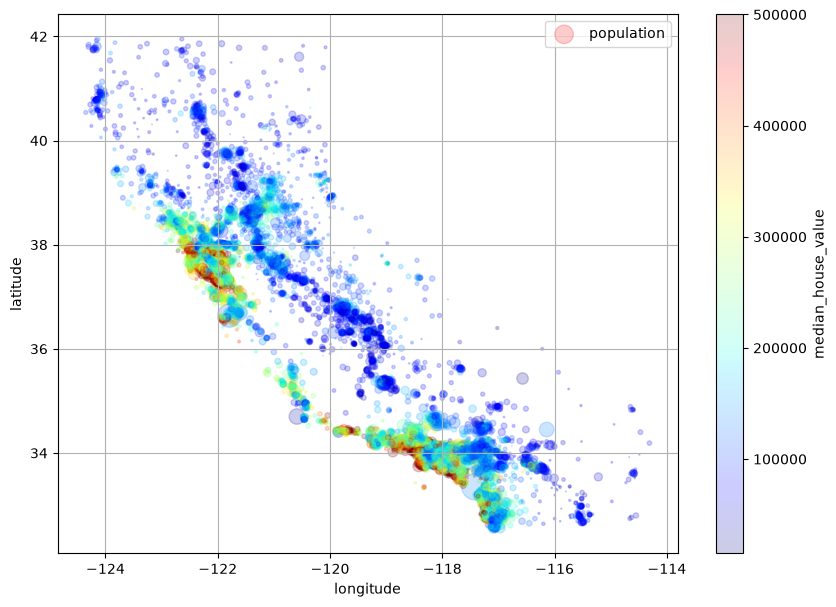

In [140]:
housing.plot(
    kind="scatter", 
    x="longitude", y="latitude", 
    grid=True, alpha=0.2,
    s=housing["population"] / 100, label="population",
    c="median_house_value", cmap="jet", colorbar=True,
    legend=True, sharex=False, figsize=(10, 7)
)

- The radius of each circle represents the population (option s)
- The color represents the price (option c)

##### Insights
- Housing prices are very much related to the location (e.g. close to the ocean) and to the population density
- The `ocean_proximty` attribute may be useful but in northern parts, house prices in coastal districts are not too high, so this is not simple rule

In [141]:
corr_matrix = housing.drop(columns=['ocean_proximity']).corr()
corr_matrix["median_house_value"].sort_values(ascending=False)

median_house_value    1.000000
median_income         0.688075
income_cat            0.643892
total_rooms           0.134153
housing_median_age    0.105623
households            0.065843
total_bedrooms        0.049686
population           -0.024650
longitude            -0.045967
latitude             -0.144160
Name: median_house_value, dtype: float64

- Correlation between pairs of each attribute using corr method
- Computed standart correlation coefficient or linear correlation or Pearson's r
- The list of correlation coeffients between median house value and every other attributes(not ocean_proximity, because it is categorical & cannot be linear) shows that strongest correlation is with `median_income`
- We can conclude that in 68% cases, the more people's income, the more house prices in those districts they live

array([[<Axes: xlabel='median_house_value', ylabel='median_house_value'>,
        <Axes: xlabel='median_income', ylabel='median_house_value'>,
        <Axes: xlabel='total_rooms', ylabel='median_house_value'>,
        <Axes: xlabel='housing_median_age', ylabel='median_house_value'>],
       [<Axes: xlabel='median_house_value', ylabel='median_income'>,
        <Axes: xlabel='median_income', ylabel='median_income'>,
        <Axes: xlabel='total_rooms', ylabel='median_income'>,
        <Axes: xlabel='housing_median_age', ylabel='median_income'>],
       [<Axes: xlabel='median_house_value', ylabel='total_rooms'>,
        <Axes: xlabel='median_income', ylabel='total_rooms'>,
        <Axes: xlabel='total_rooms', ylabel='total_rooms'>,
        <Axes: xlabel='housing_median_age', ylabel='total_rooms'>],
       [<Axes: xlabel='median_house_value', ylabel='housing_median_age'>,
        <Axes: xlabel='median_income', ylabel='housing_median_age'>,
        <Axes: xlabel='total_rooms', ylabel='housi

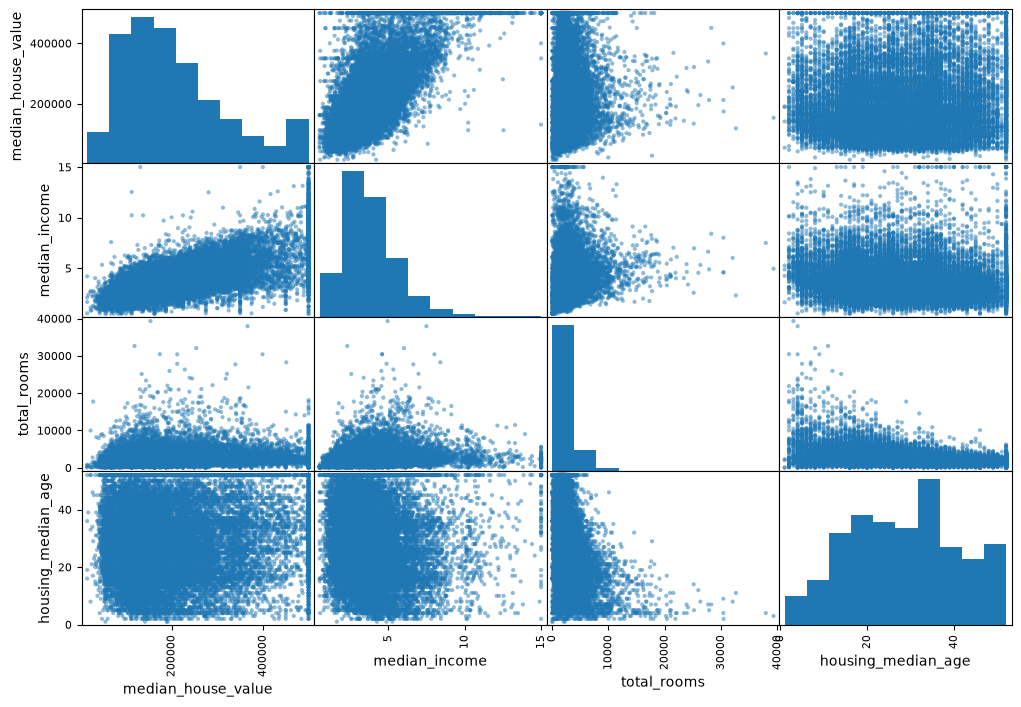

In [142]:
from pandas.plotting import scatter_matrix
attributes = ["median_house_value", "median_income", "total_rooms", "housing_median_age"]
scatter_matrix(housing[attributes], figsize=(12, 8))

- From the image we can see most promising attribute is median income, which also confirms the strong correlation calculated

##### Let's do some feature engineering
By experimenting combinations of different attributes to get more correlated features

In [143]:
housing["rooms_per_house"] = housing["total_rooms"] / housing["households"]
housing["bedrooms_ratio"] = housing["total_bedrooms"] / housing["total_rooms"]
housing["people_per_house"] = housing["population"] / housing["households"]

corr_matrix = housing.drop(columns=['ocean_proximity']).corr()
corr_matrix["median_house_value"].sort_values(ascending=False)

median_house_value    1.000000
median_income         0.688075
income_cat            0.643892
rooms_per_house       0.151948
total_rooms           0.134153
housing_median_age    0.105623
households            0.065843
total_bedrooms        0.049686
people_per_house     -0.023737
population           -0.024650
longitude            -0.045967
latitude             -0.144160
bedrooms_ratio       -0.255880
Name: median_house_value, dtype: float64

Not bad! `bedrooms_ratio` is more correlated (negative correlation) to `median_house_value` than number of rooms or bedrooms

### Preparing the Data for the Machine Learn Algorithms

In [144]:
train_set = strat_train_set.copy()
housing = train_set.drop("median_house_value", axis=1)
housing_labels = train_set["median_house_value"]

##### Data Cleaning

In [146]:

# housing.dropna(subset=["total_bedrooms"], inplace=True) # option 1: remove the rows with missing values
# housing.drop("total_bedrooms", axis=1) # option 2: drop the whole attribute

# option 3: replace missing values with median
median = housing["total_bedrooms"].median()
housing["total_bedrooms"].fillna(median, inplace=True)

/var/folders/zw/s4120bc94vdcwd8bd80yw_j80000gn/T/ipykernel_80276/2144974909.py:6: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  housing["total_bedrooms"].fillna(median, inplace=True)


13096    1115.0
14973     354.0
3785      217.0
14689     851.0
20507    1211.0
          ...  
14207     597.0
13105     592.0
19301     775.0
19121     873.0
19888     195.0
Name: total_bedrooms, Length: 16512, dtype: float64

- we have filled the `total_bedrooms` attribute of instances with median of  `total_bedrooms` values of all other instances
- this is basic task in data cleaning and getting rid of null values is important since they might mislead training process

In [96]:
from sklearn.cluster import KMeans
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.metrics.pairwise import rbf_kernel

class ClusterSimilarity(BaseEstimator, TransformerMixin):
    def __init__(self, n_clusters=10, gamma=1.0, random_state=None):
        self.n_clusters = n_clusters
        self.gamma = gamma
        self.random_state = random_state
    def fit(self, X, y=None, sample_weight=None):
        self.kmeans_ = KMeans(self.n_clusters, random_state=self.random_state) 
        self.kmeans_.fit(X, sample_weight=sample_weight)
        return self # always return self!
    def transform(self, X):
        return rbf_kernel(X, self.kmeans_.cluster_centers_, gamma=self.gamma)
    def get_feature_names_out(self, names=None):
        return [f"Cluster_{i}" for i in range(self.n_clusters)]

* We created a custom transformer called `ClusterSimilarity`.
* Transformers in machine learning modify existing features or create new features that may be more useful for predicting the target.
* `ClusterSimilarity` first learns `n_clusters` cluster centers using K-Means on the specified input features.
* During transformation, it creates one new feature per cluster.
* Each generated feature represents the similarity of a sample to one cluster center, computed using the RBF (Gaussian) kernel.
* Unlike ordinary K-Means, it does not assign each sample to a single cluster.
* Instead, every sample receives a similarity score to every cluster.
* When creating a custom transformer, core methods such as `fit()` and `transform()` are implemented (or overridden) to define how the transformer learns from the data and how it transforms new data.
* The `get_feature_names_out()` method is implemented to provide meaningful names for the generated features (e.g., `Cluster_0`, `Cluster_1`, ...).
* `ClusterSimilarity` inherits from `BaseEstimator` and `TransformerMixin`.
* `BaseEstimator` provides standard estimator functionality, including `get_params()` and `set_params()`.
* These methods are required by many scikit-learn utilities, such as:

  * `Pipeline`
  * `GridSearchCV`
  * `RandomizedSearchCV`
  * `cross_val_score`
  * model serialization (`pickle`, `joblib`)
* Because it inherits from `BaseEstimator`, the transformer behaves like any built-in scikit-learn estimator and integrates seamlessly with the scikit-learn ecosystem.
* `TransformerMixin` provides a default implementation of `fit_transform()`.
* As a result, only `fit()` and `transform()` need to be implemented when creating a custom transformer.

In [2]:
from functools import partial

from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import FunctionTransformer, StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer, make_column_selector

def column_ratio(X):
    return X[:, [0]] / X[:, [1]]


def ratio_feature_names_out(name, transformer, feature_names):
    return [name]


def ratio_pipeline(name=None):
    return make_pipeline(
        SimpleImputer(strategy="median"),
        FunctionTransformer(column_ratio, validate=False, feature_names_out=partial(ratio_feature_names_out, name)),
        StandardScaler()
    )
    
log_pipeline = make_pipeline(
    SimpleImputer(strategy="median"),
    FunctionTransformer(
        np.log,
        validate=False,
        feature_names_out="one-to-one"
    ),
    StandardScaler()
)

cat_pipeline = make_pipeline(
    SimpleImputer(strategy="most_frequent"),
    OrdinalEncoder(dtype=np.int64),
    OneHotEncoder(handle_unknown="ignore")
)

cluster_simil = ClusterSimilarity(n_clusters=10, gamma=1.0, random_state=42)

default_num_pipeline = make_pipeline(
    SimpleImputer(strategy="median"),
    StandardScaler()
)

# Hamma transformerlarni birlashtirish
preprocessor = ColumnTransformer([
    ("bedrooms_ratio", ratio_pipeline(name="bedrooms_ratio"), ["total_bedrooms", "total_rooms"]),
    ("rooms_per_house", ratio_pipeline(name="rooms_per_house"), ["total_rooms", "households"]),
    ("people_per_house", ratio_pipeline(name="people_per_house"), ["population", "households"]),
    ("log", log_pipeline, ["total_bedrooms", "total_rooms", "population", "households", "median_income"]),
    ("geo", cluster_simil, ["latitude", "longitude"]),
    ("cat", cat_pipeline, make_column_selector(dtype_include=object))],
    remainder=default_num_pipeline
)

NameError: name 'np' is not defined

- In this block of code, we gonna design and define our all transformations based on insights gotten from dataset description and discoveries
- We might use these preprocessing/transformations in several times later in training and fine-tuning stages
- So Let's make it reusable using `ColumnTransformer` class which can combine all transformation pipelines into single variable which inputs whole housing dataset/subsets in raw format after split
-  we can pass our custom functions right inside of transformation flow
- First tranformation pipeline is `ratio_pipeline` which inputs 2 features from the dataset, fills null values with medians using `SimpleImputer`, `FunctionTransformer` injects the `column_ratio` function which calculates the division of 2 input features, and lastly `StandardScaler` scales values of computed feature values
- As we see, `ratio_pipeline` is used several times to calculate 3 other features which are possibly correlated to the target feature, such as `bedrooms_ratio`, `rooms_per_house`, `people_per_house` using pairs of other features
- `log_pipeline`'s job is to normalize skeewed data because most of real-world  features, such as ones specified in code block, are not normally distributed 
- the next transformation using our custom `ClusterSimilarity` transformer is to make `n` number of clusters, each as individual features which have prefix of `geo__Cluster_n_`, having numerical values that shows how they are close to median, 
- last sub-pipeline is `cat_pipeline`, and it one-hot encodes all features where `data_type` is object(string, etc.)
- we setting `remainder` to `default_num_pipeline`, that simply imputes(fills nulls) and scales

In [150]:
housing_prepared = preprocessor.fit_transform(housing)
print("Original shape:", housing.shape)
print("Prepared shape:", housing_prepared.shape)

Original shape: (16512, 9)
Prepared shape: (16512, 24)


The result is 9 features + 15 new features: `10` from cluster similarity pipeline and `5` from one-hot encoded `ocean_proximity` feature

In [99]:
preprocessor.get_feature_names_out()

array(['bedrooms_ratio__bedrooms_ratio',
       'rooms_per_house__rooms_per_house',
       'people_per_house__people_per_house', 'log__total_bedrooms',
       'log__total_rooms', 'log__population', 'log__households',
       'log__median_income', 'geo__Cluster_0', 'geo__Cluster_1',
       'geo__Cluster_2', 'geo__Cluster_3', 'geo__Cluster_4',
       'geo__Cluster_5', 'geo__Cluster_6', 'geo__Cluster_7',
       'geo__Cluster_8', 'geo__Cluster_9', 'cat__ocean_proximity_0',
       'cat__ocean_proximity_1', 'cat__ocean_proximity_2',
       'cat__ocean_proximity_3', 'cat__ocean_proximity_4',
       'remainder__housing_median_age'], dtype=object)

- OK, our preprocessor is working fine let's move to the next phase

### Selecting & Training Model

- To begin, we are gonna use `LinearRegression` model to see how our data performs with simpliest model
- On top of that, this first step shows feature importances when calculating the target

In [100]:
from sklearn.linear_model import LinearRegression

lin_reg = make_pipeline(
    preprocessor,
    LinearRegression()
)
lin_reg.fit(housing, housing_labels)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('columntransformer', ...), ('linearregression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](9,)","['longitude','latitude','housing_median_age',...,'households', 'median_income','ocean_proximity']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,9
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('bedrooms_ratio', ...), ('rooms_per_house', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedt

In [101]:
housing_predictions = lin_reg.predict(housing)
housing_predictions[:5].round(-2)


array([246000., 372700., 135700.,  91400., 330900.])

In [102]:
housing_labels.iloc[:5].values


array([458300., 483800., 101700.,  96100., 361800.])

- Predictions of `LinearRegression` are not even close to GTs
- Let's calculate Root Mean Squared Error using predictions and GTs

In [103]:
from sklearn.metrics import mean_squared_error

lin_rmse = mean_squared_error(housing_labels, housing_predictions) ** 0.5
lin_rmse

68972.88910758459

- Trained `LinearRegression` on train set
- Predicted targets on whole dataset
- Compared predictions with GT labels and found that our model can mistake by ~69K $ which is not very satifying
- Decided to try `DecisionTreeRegressor` to find complex nonlinear relationships in the data

In [151]:
from sklearn.tree import DecisionTreeRegressor

tree_reg = make_pipeline(preprocessor, DecisionTreeRegressor(random_state=42))
tree_reg.fit(housing, housing_labels)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('columntransformer', ...), ('decisiontreeregressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](9,)","['longitude','latitude','housing_median_age',...,'households', 'median_income','ocean_proximity']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,9
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('bedrooms_ratio', ...), ('rooms_per_house', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data pa

In [152]:
housing_predictions = tree_reg.predict(housing)
tree_rmse = mean_squared_error(housing_labels, housing_predictions) ** 0.5
tree_rmse

0.0

- Root Mean Squared Error shows 0.0 error that shows model badly overfit the data
- Let's try better evaluation with cross-validation

In [153]:
from sklearn.model_selection import cross_val_score

tree_rmses = -cross_val_score(tree_reg, housing, housing_labels, scoring="neg_root_mean_squared_error", cv=10)
pd.Series(tree_rmses).describe()

count       10.000000
mean     67013.360949
std       1460.198570
min      64289.376198
25%      66776.146282
50%      67086.216281
75%      68140.275029
max      68659.294290
dtype: float64

- Now we can see, decisionTree model is preforming only slightly better than linearRegression model thanks to bad overfits
- Let's try RandomForestRegressor, ensemble model, which is composed of many other models 

In [154]:
from sklearn.ensemble import RandomForestRegressor

forest_reg = make_pipeline(preprocessor, RandomForestRegressor(random_state=42))
forest_rmses = -cross_val_score(forest_reg, housing, housing_labels, scoring="neg_root_mean_squared_error", cv=10)
pd.Series(forest_rmses).describe()

count       10.000000
mean     47124.604437
std       1069.311372
min      45292.329302
25%      46712.106520
50%      47172.209883
75%      47561.377695
max      49354.705514
dtype: float64

- Error rates much lower than other two models but still model is overfitting the data
- Possible solution is to regularize the model by reducing its complexity or to add more training data
- First possible solution is done by fine-tuning the model, by trying different hyperparametres for model before training and getting best hyperparamters
- Let's try the grid-search which is the one type of cross validation to find most optimal hyperparamter values

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline

full_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("random_forest", RandomForestRegressor(random_state=42))
])

param_grid = [
    {'preprocessing__geo__n_clusters': [5, 8, 10],
    'random_forest__max_features': [4, 6, 8]},
    {'preprocessing__geo__n_clusters': [10, 15],
    'random_forest__max_features': [6, 8, 10]},
]

grid_search = GridSearchCV(full_pipeline, param_grid, cv=3, scoring='neg_root_mean_squared_error')
grid_search.fit(housing, housing_labels)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'preprocessing__geo__n_clusters': [5, 8, ...], 'random_forest__max_features': [4, 6, ...]}, {'preprocessing__geo__n_clusters': [10, 15], 'random_forest__max_features': [6, 8, ...]}]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cr

In [156]:
grid_search.best_params_

{'preprocessing__geo__n_clusters': 15, 'random_forest__max_features': 6}

- The best parameters for `n_clusters` and `max_features`

In [157]:
cv_res = pd.DataFrame(grid_search.cv_results_)
cv_res.sort_values(by='mean_test_score', ascending=False, inplace=True)
cv_res.head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_preprocessing__geo__n_clusters,param_random_forest__max_features,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score
12,2.469508,0.032658,0.095201,0.000377,15,6,"{'preprocessing__geo__n_clusters': 15, 'random...",-43524.105676,-43958.237963,-44759.841846,-44080.728495,511.868419,1
13,3.151769,0.004982,0.094784,0.000601,15,8,"{'preprocessing__geo__n_clusters': 15, 'random...",-44027.285408,-44179.627865,-45001.117086,-44402.676786,427.707182,2
14,3.905194,0.038859,0.116239,0.017525,15,10,"{'preprocessing__geo__n_clusters': 15, 'random...",-44410.909192,-44618.770051,-45423.947846,-44817.875696,436.878413,3
7,2.408381,0.010052,0.095399,0.001436,10,6,"{'preprocessing__geo__n_clusters': 10, 'random...",-44251.874824,-44825.226423,-45610.878897,-44895.993382,557.063126,4
9,2.397433,0.016254,0.094109,0.000433,10,6,"{'preprocessing__geo__n_clusters': 10, 'random...",-44251.874824,-44825.226423,-45610.878897,-44895.993382,557.063126,4


- `GridSearchCV` searches for the best hyperparameters by evaluating every possible combination of the values you provide. This guarantees that the best combination within that grid is found, but it becomes slow as the number of parameters and candidate values increases.

- `RandomizedSearchCV` samples a fixed number of random combinations from the specified parameter distributions or lists. Because it doesn't evaluate every combination, it's much faster and lets you search a much larger hyperparameter space, including continuous ranges, while often finding nearly optimal results.

In [160]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint
param_distribs = {'preprocessing__geo__n_clusters': randint(low=3,high=50),
'random_forest__max_features': randint(low=2,high=20)}
rnd_search = RandomizedSearchCV(
    full_pipeline, param_distributions=param_distribs, n_iter=10,
    cv=3, scoring='neg_root_mean_squared_error', random_state=42)
rnd_search.fit(housing, housing_labels)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'preprocessing__geo__n_clusters': <scipy.stats....t 0x11e81c1a0>, 'random_forest__max_features': <scipy.stats....t 0x11fe78e10>}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_root_mean_squared_error'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchC

- `RandomForestRegressor` model has `feature_importances_` attribute
- `feature_importances_` shows sorted list of features based on the importance level of each feature
- below we get the `feature_importances_` of best model gotten from `RandomizedSearchCV`

In [161]:
final_model = rnd_search.best_estimator_
feature_importances = final_model['random_forest'].feature_importances_

feature_importances.round(2)

array([0.06, 0.06, 0.05, 0.01, 0.01, 0.01, 0.01, 0.19, 0.01, 0.02, 0.01,
       0.02, 0.01, 0.  , 0.01, 0.01, 0.01, 0.02, 0.01, 0.  , 0.01, 0.01,
       0.01, 0.  , 0.01, 0.  , 0.02, 0.01, 0.01, 0.  , 0.01, 0.01, 0.01,
       0.02, 0.02, 0.01, 0.01, 0.01, 0.04, 0.01, 0.02, 0.01, 0.01, 0.01,
       0.02, 0.01, 0.  , 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.  , 0.08,
       0.  , 0.  , 0.  , 0.01])

- Let's view the importance of each feature alongside its corresponding feature name.

In [163]:
sorted(zip(feature_importances.round(2), final_model["preprocessing"].get_feature_names_out()), key=lambda x: x[0], reverse=True)

[(np.float64(0.19), 'log__median_income'),
 (np.float64(0.08), 'cat__ocean_proximity_1'),
 (np.float64(0.06), 'bedrooms_ratio__bedrooms_ratio'),
 (np.float64(0.06), 'rooms_per_house__rooms_per_house'),
 (np.float64(0.05), 'people_per_house__people_per_house'),
 (np.float64(0.04), 'geo__Cluster_30'),
 (np.float64(0.02), 'geo__Cluster_1'),
 (np.float64(0.02), 'geo__Cluster_3'),
 (np.float64(0.02), 'geo__Cluster_9'),
 (np.float64(0.02), 'geo__Cluster_18'),
 (np.float64(0.02), 'geo__Cluster_25'),
 (np.float64(0.02), 'geo__Cluster_26'),
 (np.float64(0.02), 'geo__Cluster_32'),
 (np.float64(0.02), 'geo__Cluster_36'),
 (np.float64(0.01), 'log__total_bedrooms'),
 (np.float64(0.01), 'log__total_rooms'),
 (np.float64(0.01), 'log__population'),
 (np.float64(0.01), 'log__households'),
 (np.float64(0.01), 'geo__Cluster_0'),
 (np.float64(0.01), 'geo__Cluster_2'),
 (np.float64(0.01), 'geo__Cluster_4'),
 (np.float64(0.01), 'geo__Cluster_6'),
 (np.float64(0.01), 'geo__Cluster_7'),
 (np.float64(0.01), 'g

### Evaluate our model in test set

In [164]:
X_test = strat_test_set.drop("median_house_value", axis=1)
y_test = strat_test_set["median_house_value"].copy()

final_predictions = final_model.predict(X_test)
final_rmse = mean_squared_error(y_test, final_predictions) ** 0.5

print(final_rmse)

41423.082068461576


- This is best result since start of experimentations
- Best Model Since: `RandomForestRegressor`

In [ ]:
# export the final model to a file
import joblib
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline

export_model = Pipeline([
    ("preprocessing", preprocessor),
    ("random_forest", RandomForestRegressor(random_state=42, **{
        key.split("__", 1)[1]: value for key, value in rnd_search.best_params_.items() if key.startswith("random_forest__")
    }))
])
export_model.fit(housing, housing_labels)
joblib.dump(export_model, "weights/my_california_housing_model.pkl")

#### Reload trained model weights later in production as following 

In [ ]:
loaded_model = joblib.load("weights/my_california_housing_model.pkl")

predictions = loaded_model.predict(X_test)

rmse = mean_squared_error(y_test, predictions) ** 0.5
print(rmse)

# Exercises

In [108]:
from tqdm.auto import tqdm
from joblib import Parallel, delayed
from contextlib import contextmanager
import joblib

@contextmanager
def tqdm_joblib(tqdm_object):
    class TqdmBatchCompletionCallback(joblib.parallel.BatchCompletionCallBack):
        def __call__(self, *args, **kwargs):
            tqdm_object.update(n=self.batch_size)
            return super().__call__(*args, **kwargs)

    old_callback = joblib.parallel.BatchCompletionCallBack
    joblib.parallel.BatchCompletionCallBack = TqdmBatchCompletionCallback
    try:
        yield
    finally:
        joblib.parallel.BatchCompletionCallBack = old_callback

# Exercise solutions

## 1.

Exercise: Try a Support Vector Machine regressor (sklearn.svm.SVR) with various hyperparameters, such as kernel="linear" (with various values for the C hyperparameter) or kernel="rbf" (with various values for the C and gamma hyperparameters). Note that SVMs don't scale well to large datasets, so you should probably train your model on just the first 5,000 instances of the training set and use only 3-fold cross-validation, or else it will take hours. Don't worry about what the hyperparameters mean for now (see the SVM notebook if you're interested). How does the best SVR predictor perform?

In [1]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVR

param_grid = [
        {'svr__kernel': ['linear'], 'svr__C': [10., 30., 100., 300., 1000.,
                                               3000., 10000., 30000.0]},
        {'svr__kernel': ['rbf'], 'svr__C': [1.0, 3.0, 10., 30., 100., 300.,
                                            1000.0],
         'svr__gamma': [0.01, 0.03, 0.1, 0.3, 1.0, 3.0]},
    ]

svr_pipeline = Pipeline([("preprocessing", preprocessor), ("svr", SVR())])
grid_search = GridSearchCV(svr_pipeline, param_grid, cv=3,
                           scoring='neg_root_mean_squared_error')
grid_search.fit(housing.iloc[:5000], housing_labels.iloc[:5000])

NameError: name 'Pipeline' is not defined

The best model achieves the following score (evaluated using 3-fold cross validation):

In [45]:
svr_grid_search_rmse = -grid_search.best_score_
svr_grid_search_rmse

np.float64(70059.92773220727)

That's much worse than the `RandomForestRegressor` (but to be fair, we trained the model on much less data). Let's check the best hyperparameters found:

## 2.

- Exercise: _Try replacing the `GridSearchCV` with a `RandomizedSearchCV`.
- **Warning:** the following cell will take several minutes to run. You can specify `verbose=2` when creating the `RandomizedSearchCV` if you want to see the training details.

In [46]:
grid_search.best_params_

{'svr__C': 10000.0, 'svr__kernel': 'linear'}

In [40]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import expon, loguniform
from sklearn.pipeline import Pipeline
from sklearn.svm import SVR

# see https://docs.scipy.org/doc/scipy/reference/stats.html
# for `expon()` and `loguniform()` documentation and more probability distribution functions.

# Note: gamma is ignored when kernel is "linear"
param_distribs = {
        'svr__kernel': ['linear', 'rbf'],
        'svr__C': loguniform(20, 200_000),
        'svr__gamma': expon(scale=1.0),
    }
svr_pipeline = Pipeline([("preprocessing", preprocessor), ("svr", SVR())])
rnd_search = RandomizedSearchCV(svr_pipeline,
                                param_distributions=param_distribs,
                                n_iter=50, cv=3,
                                scoring='neg_root_mean_squared_error',
                                random_state=42)
rnd_search.fit(housing.iloc[:5000], housing_labels.iloc[:5000])

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...svr', SVR())])"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'svr__C': <scipy.stats....t 0x11b7c5750>, 'svr__gamma': <scipy.stats....t 0x11b7c5950>, 'svr__kernel': ['linear', 'rbf']}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",50
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_root_mean_squared_error'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` i

The best model achieves the following score (evaluated using 3-fold cross validation):

In [41]:
svr_rnd_search_rmse = -rnd_search.best_score_
svr_rnd_search_rmse

np.float64(56152.05370505311)

Now that's really much better, but still far from the `RandomForestRegressor`'s performance. Let's check the best hyperparameters found:

In [42]:
rnd_search.best_params_

{'svr__C': np.float64(157055.10989448498),
 'svr__gamma': np.float64(0.26497040005002437),
 'svr__kernel': 'rbf'}

This time the search found a good set of hyperparameters for the RBF kernel. Randomized search tends to find better hyperparameters than grid search in the same amount of time.

Note that we used the expon() distribution for gamma, with a scale of 1, so RandomSearch mostly searched for values roughly of that scale: about 80% of the samples were between 0.1 and 2.3 (roughly 10% were smaller and 10% were larger):

In [110]:
from sklearn.feature_selection import SelectFromModel

selector_pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('selector', SelectFromModel(RandomForestRegressor(random_state=42),
                                 threshold=0.005)),
    ('svr', SVR(C=rnd_search.best_params_["svr__C"],
                gamma=rnd_search.best_params_["svr__gamma"],
                kernel=rnd_search.best_params_["svr__kernel"])),
])

In [73]:
from sklearn.model_selection import cross_val_score

selector_rmses = -cross_val_score(selector_pipeline,
                                  housing.iloc[:5000],
                                  housing_labels.iloc[:5000],
                                  scoring="neg_root_mean_squared_error",
                                  cv=3)
pd.Series(selector_rmses).describe()

count         3.000000
mean      98795.629197
std        2819.328598
min       96457.569352
25%       97230.206383
50%       98002.843415
75%       99964.659120
max      101926.474826
dtype: float64

## 3.

Exercise: _Try adding a `SelectFromModel` transformer in the preparation pipeline to select only the most important attributes._

Let's create a new pipeline that runs the previously defined preparation pipeline, and adds a `SelectFromModel` transformer based on a `RandomForestRegressor` before the final regressor:

In [111]:
param_distribs = {
        'svr__kernel': ['linear', 'rbf'],
        'svr__C': loguniform(20, 200_000),
        'svr__gamma': expon(scale=1.0),
        'selector__threshold': [0.001, 0.005, 0.01, 0.05, 0.1]
    }

param_distribs = {k: [v] for k, v in rnd_search.best_params_.items()}

param_distribs["selector__threshold"] = [0.001, 0.005, 0.01, 0.05, 0.1]

rnd_selector_search = RandomizedSearchCV(selector_pipeline,
                                param_distributions=param_distribs,
                                n_iter=50, cv=3,
                                scoring='neg_root_mean_squared_error',
                                random_state=42)
rnd_selector_search.fit(housing.iloc[:5000], housing_labels.iloc[:5000])

/Users/yusufaxmad/Documents/ai/learning/ML-learning/.venv/lib/python3.14/site-packages/sklearn/model_selection/_search.py:326: UserWarning: The total space of parameters 5 is smaller than n_iter=50. Running 5 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...005002437)))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'selector__threshold': [0.001, 0.005, ...], 'svr__C': [np.float64(157055.10989448498)], 'svr__gamma': [np.float64(0....7040005002437)], 'svr__kernel': ['rbf']}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",50
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_root_mean_squared_error'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` dire

Oh well, feature selection does not seem to help. But maybe that's just because the threshold we used was not optimal. Perhaps try tuning it using random search or grid search?

In [112]:
rnd_selector_search.best_params_, rnd_selector_search.best_score_

({'svr__kernel': 'rbf',
  'svr__gamma': np.float64(0.26497040005002437),
  'svr__C': np.float64(157055.10989448498),
  'selector__threshold': 0.001},
 np.float64(-56285.974161766375))

## 4.

Exercise: _Try creating a custom transformer that trains a k-Nearest Neighbors regressor (`sklearn.neighbors.KNeighborsRegressor`) in its `fit()` method, and outputs the model's predictions in its `transform()` method. Then add this feature to the preprocessing pipeline, using latitude and longitude as the inputs to this transformer. This will add a feature in the model that corresponds to the housing median price of the nearest districts._

Rather than restrict ourselves to k-Nearest Neighbors regressors, let's create a transformer that accepts any regressor. For this, we can extend the `MetaEstimatorMixin` and have a required `estimator` argument in the constructor. The `fit()` method must work on a clone of this estimator, and it must also save `feature_names_in_`. The `MetaEstimatorMixin` will ensure that `estimator` is listed as a required parameters, and it will update `get_params()` and `set_params()` to make the estimator's hyperparameters available for tuning. Lastly, we create a `get_feature_names_out()` method: the output column name is the ...

In [113]:
from sklearn.base import BaseEstimator, TransformerMixin, MetaEstimatorMixin, clone
from sklearn.neighbors import KNeighborsRegressor
from sklearn.utils.validation import check_is_fitted
from sklearn.utils.validation import validate_data

class CustomKNNRegressorTransformer(MetaEstimatorMixin, TransformerMixin, BaseEstimator):
    def __init__(self, estimator):
        self.estimator = estimator
    
    def fit(self, X, y):
        X, y = validate_data(self, X, y, reset=True)
        
        self.estimator_ = clone(self.estimator)
        self.estimator_.fit(X, y)
        self.n_features_in_ = self.estimator_.n_features_in_
        if hasattr(self.estimator_, "feature_names_in_"):
            self.feature_names_in_ = self.estimator_.feature_names_in_
        return self  # always return self!

    def transform(self, X):
        check_is_fitted(self)
        
        X = validate_data(self, X, reset=False)
        
        predictions = self.estimator_.predict(X)
        if predictions.ndim == 1:
            predictions = predictions.reshape(-1, 1)
        return predictions
    
    def get_feature_names_out(self, names=None):
        check_is_fitted(self)
        n_outputs = getattr(self.estimator_, "n_outputs_", 1)
        estimator_class_name = self.estimator_.__class__.__name__
        estimator_short_name = estimator_class_name.lower().replace("_", "")
        return [f"{estimator_short_name}_prediction_{i}"
                for i in range(n_outputs)]

Let's ensure it complies to Scikit-Learn's API:

In [114]:
from sklearn.utils.estimator_checks import check_estimator

check_estimator(CustomKNNRegressorTransformer(KNeighborsRegressor()))

/Users/yusufaxmad/Documents/ai/learning/ML-learning/.venv/lib/python3.14/site-packages/sklearn/utils/estimator_checks.py:918: SkipTestWarning: Skipping check check_array_api_input for CustomKNNRegressorTransformer because it raised SkipTest: SCIPY_ARRAY_API is not set: not checking array_api input
  warnings.warn(


[{'estimator': CustomKNNRegressorTransformer(estimator=KNeighborsRegressor()),
  'check_name': 'check_estimator_cloneable',
  'exception': None,
  'status': 'passed',
  'expected_to_fail': False,
  'expected_to_fail_reason': 'Check is not expected to fail'},
 {'estimator': CustomKNNRegressorTransformer(estimator=KNeighborsRegressor()),
  'check_name': 'check_estimator_tags_renamed',
  'exception': None,
  'status': 'passed',
  'expected_to_fail': False,
  'expected_to_fail_reason': 'Check is not expected to fail'},
 {'estimator': CustomKNNRegressorTransformer(estimator=KNeighborsRegressor()),
  'check_name': 'check_valid_tag_types',
  'exception': None,
  'status': 'passed',
  'expected_to_fail': False,
  'expected_to_fail_reason': 'Check is not expected to fail'},
 {'estimator': CustomKNNRegressorTransformer(estimator=KNeighborsRegressor()),
  'check_name': 'check_estimator_repr',
  'exception': None,
  'status': 'passed',
  'expected_to_fail': False,
  'expected_to_fail_reason': 'Che

Good! Now let's test it:

In [ ]:
geo_reg_pipeline = make_pipeline(
    CustomKNNRegressorTransformer(KNeighborsRegressor())
)

preprocessor = ColumnTransformer([
    ("bedrooms_ratio", ratio_pipeline(name="bedrooms_ratio"), ["total_bedrooms", "total_rooms"]),
    ("rooms_per_house", ratio_pipeline(name="rooms_per_house"), ["total_rooms", "households"]),
    ("people_per_house", ratio_pipeline(name="people_per_house"), ["population", "households"]),
    ("log", log_pipeline, ["total_bedrooms", "total_rooms", "population", "households", "median_income"]),
    ("geo", cluster_simil, ["latitude", "longitude"]),
    ("geo_reg", geo_reg_pipeline, ["latitude", "longitude"]),
    ("cat", cat_pipeline, make_column_selector(dtype_include=object))],
    remainder=default_num_pipeline
)

And what does its output feature name look like?

In [118]:
preprocessor.fit(housing, housing_labels)
preprocessor.get_feature_names_out()

array(['bedrooms_ratio__bedrooms_ratio',
       'rooms_per_house__rooms_per_house',
       'people_per_house__people_per_house', 'log__total_bedrooms',
       'log__total_rooms', 'log__population', 'log__households',
       'log__median_income', 'geo__Cluster_0', 'geo__Cluster_1',
       'geo__Cluster_2', 'geo__Cluster_3', 'geo__Cluster_4',
       'geo__Cluster_5', 'geo__Cluster_6', 'geo__Cluster_7',
       'geo__Cluster_8', 'geo__Cluster_9',
       'geo_reg__kneighborsregressor_prediction_0',
       'cat__ocean_proximity_0', 'cat__ocean_proximity_1',
       'cat__ocean_proximity_2', 'cat__ocean_proximity_3',
       'cat__ocean_proximity_4', 'remainder__housing_median_age'],
      dtype=object)

In [116]:
from sklearn.feature_selection import SelectFromModel
from sklearn.ensemble import RandomForestRegressor

selector_pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('selector', SelectFromModel(RandomForestRegressor(random_state=42),
                                 threshold=rnd_selector_search.best_params_["selector__threshold"])),
    ('svr', SVR(C=rnd_selector_search.best_params_["svr__C"],
                gamma=rnd_selector_search.best_params_["svr__gamma"],
                kernel=rnd_selector_search.best_params_["svr__kernel"])),
])

In [117]:
selector_pipeline.fit(housing, housing_labels)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessing', ...), ('selector', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](9,)","['longitude','latitude','housing_median_age',...,'households', 'median_income','ocean_proximity']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,9
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('bedrooms_ratio', ...), ('rooms_per_house', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit`

In [121]:
predictions = selector_pipeline.predict(X_test)

In [ ]:
rmse = mean_squared_error(y_test, predictions) ** 0.5
print(f"Root Mean Squared Error after adding new transformer: {rmse}")

Root Mean Squared Error: 87714.30081606991


In [ ]:
predictions = selector_pipeline.predict(X_test)